In [1]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import AlexNet_Weights
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

In [2]:
# Load pretrained AlexNet
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

weights = AlexNet_Weights.IMAGENET1K_V1
alexnet = models.alexnet(weights=weights)
alexnet.to(device)
alexnet.eval()

# Get the preprocessing transform
transform = weights.transforms()
print("\nTransform:")
print(transform)

Using device: cuda

Transform:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [3]:
# Print the full AlexNet architecture
print("AlexNet Architecture:")
print("\nFeatures (Convolutional layers):")
for i, layer in enumerate(alexnet.features):
    print(f"  Layer {i}: {layer}")

print("\nAvgpool:")
print(f"  {alexnet.avgpool}")

print("\nClassifier (Fully connected layers):")
for i, layer in enumerate(alexnet.classifier):
    print(f"  Layer {i}: {layer}")

AlexNet Architecture:

Features (Convolutional layers):
  Layer 0: Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
  Layer 1: ReLU(inplace=True)
  Layer 2: MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  Layer 3: Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  Layer 4: ReLU(inplace=True)
  Layer 5: MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  Layer 6: Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  Layer 7: ReLU(inplace=True)
  Layer 8: Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  Layer 9: ReLU(inplace=True)
  Layer 10: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  Layer 11: ReLU(inplace=True)
  Layer 12: MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)

Avgpool:
  AdaptiveAvgPool2d(output_size=(6, 6))

Classifier (Fully connected layers):
  Layer 0: Dropout(p=0.5, inplace=False)
  Layer 1: 

loading annotations into memory...
Done (t=3.96s)
creating index...
index created!
Using COCO dataset image


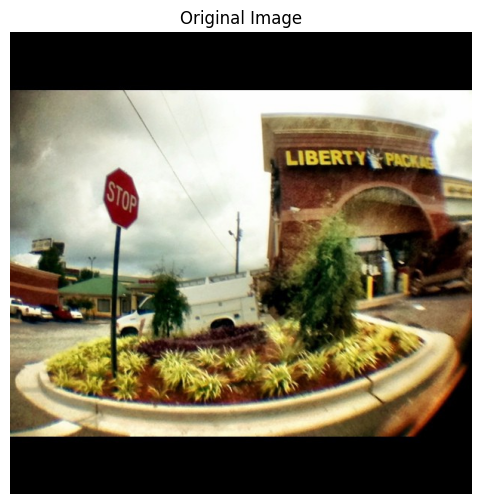

Original image size: (612, 612)


In [12]:
# Load an example ImageNet image
# Option 1: Use PyTorch's sample images
# Option 2: Use an image from COCO dataset

USE_COCO = True  # Set to True to use COCO dataset, False to download sample image

if USE_COCO:
    # Use COCO dataset
    from dataset_handler import COCODatasetHandler
    
    coco = COCODatasetHandler("../CoCo", "train2017")
    # Get a dog image from COCO (similar to ImageNet classes)
    instances = coco.find_instances("stop sign", 1, max_area=3000, min_area=2000, grayscale=False)
    img = instances[0]['image']
    print("Using COCO dataset image")
    
else:
    # Download sample from PyTorch repository
    try:
        from torchvision.datasets.utils import download_url
        import os
        
        # Download a sample ImageNet image
        url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"
        download_path = "/tmp/imagenet_sample.jpg"
        
        if not os.path.exists(download_path):
            download_url(url, '/tmp', 'imagenet_sample.jpg')
        
        img = Image.open(download_path).convert('RGB')
        print("Using PyTorch sample image")
        
    except Exception as e:
        print(f"Could not download image: {e}")
        print("Creating a random image for demonstration...")
        # Fallback: create a random image
        img = Image.fromarray(np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8))

# Display the original image
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

print(f"Original image size: {img.size}")

In [13]:
# Preprocess the image
img_tensor = transform(img).unsqueeze(0).to(device)
print(f"Input tensor shape: {img_tensor.shape}")
print(f"Input tensor range: [{img_tensor.min():.4f}, {img_tensor.max():.4f}]")
print(f"Input tensor mean: {img_tensor.mean():.4f}")
print(f"Input tensor std: {img_tensor.std():.4f}")

Input tensor shape: torch.Size([1, 3, 224, 224])
Input tensor range: [-2.1179, 2.6400]
Input tensor mean: 0.0615
Input tensor std: 1.5175


In [14]:
def step_through_network(model, x, verbose=True):
    """
    Step through the entire AlexNet network layer by layer.
    Returns a list of tuples: (layer_name, layer_module, output_tensor, stats)
    """
    layer_outputs = []
    
    with torch.no_grad():
        # Current activation
        activation = x
        
        # Store input statistics
        stats = {
            'shape': tuple(activation.shape),
            'min': activation.min().item(),
            'max': activation.max().item(),
            'mean': activation.mean().item(),
            'std': activation.std().item(),
            'num_zeros': (activation == 0).sum().item(),
            'num_elements': activation.numel(),
            'sparsity': (activation == 0).sum().item() / activation.numel()
        }
        layer_outputs.append(('input', None, activation.clone(), stats))
        
        if verbose:
            print(f"{'='*80}")
            print(f"INPUT")
            print(f"  Shape: {stats['shape']}")
            print(f"  Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
            print(f"  Mean: {stats['mean']:.4f}, Std: {stats['std']:.4f}")
            print(f"  Sparsity: {stats['sparsity']*100:.2f}%")
        
        # Step through feature layers (convolutional part)
        for i, layer in enumerate(model.features):
            activation = layer(activation)
            
            stats = {
                'shape': tuple(activation.shape),
                'min': activation.min().item(),
                'max': activation.max().item(),
                'mean': activation.mean().item(),
                'std': activation.std().item(),
                'num_zeros': (activation == 0).sum().item(),
                'num_elements': activation.numel(),
                'sparsity': (activation == 0).sum().item() / activation.numel()
            }
            
            layer_name = f"features.{i}"
            layer_outputs.append((layer_name, layer, activation.clone(), stats))
            
            if verbose:
                print(f"\n{'='*80}")
                print(f"Layer {i}: {layer.__class__.__name__}")
                print(f"  {layer}")
                print(f"  Output shape: {stats['shape']}")
                print(f"  Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
                print(f"  Mean: {stats['mean']:.4f}, Std: {stats['std']:.4f}")
                print(f"  Sparsity: {stats['sparsity']*100:.2f}%")
        
        # Step through avgpool
        activation = model.avgpool(activation)
        stats = {
            'shape': tuple(activation.shape),
            'min': activation.min().item(),
            'max': activation.max().item(),
            'mean': activation.mean().item(),
            'std': activation.std().item(),
            'num_zeros': (activation == 0).sum().item(),
            'num_elements': activation.numel(),
            'sparsity': (activation == 0).sum().item() / activation.numel()
        }
        layer_outputs.append(('avgpool', model.avgpool, activation.clone(), stats))
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"AvgPool: {model.avgpool}")
            print(f"  Output shape: {stats['shape']}")
            print(f"  Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
            print(f"  Mean: {stats['mean']:.4f}, Std: {stats['std']:.4f}")
            print(f"  Sparsity: {stats['sparsity']*100:.2f}%")
        
        # Flatten
        activation = torch.flatten(activation, 1)
        stats = {
            'shape': tuple(activation.shape),
            'min': activation.min().item(),
            'max': activation.max().item(),
            'mean': activation.mean().item(),
            'std': activation.std().item(),
            'num_zeros': (activation == 0).sum().item(),
            'num_elements': activation.numel(),
            'sparsity': (activation == 0).sum().item() / activation.numel()
        }
        layer_outputs.append(('flatten', None, activation.clone(), stats))
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"Flatten")
            print(f"  Output shape: {stats['shape']}")
            print(f"  Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
            print(f"  Mean: {stats['mean']:.4f}, Std: {stats['std']:.4f}")
            print(f"  Sparsity: {stats['sparsity']*100:.2f}%")
        
        # Step through classifier layers (fully connected part)
        for i, layer in enumerate(model.classifier):
            activation = layer(activation)
            
            stats = {
                'shape': tuple(activation.shape),
                'min': activation.min().item(),
                'max': activation.max().item(),
                'mean': activation.mean().item(),
                'std': activation.std().item(),
                'num_zeros': (activation == 0).sum().item(),
                'num_elements': activation.numel(),
                'sparsity': (activation == 0).sum().item() / activation.numel()
            }
            
            layer_name = f"classifier.{i}"
            layer_outputs.append((layer_name, layer, activation.clone(), stats))
            
            if verbose:
                print(f"\n{'='*80}")
                print(f"Classifier {i}: {layer.__class__.__name__}")
                print(f"  {layer}")
                print(f"  Output shape: {stats['shape']}")
                print(f"  Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
                print(f"  Mean: {stats['mean']:.4f}, Std: {stats['std']:.4f}")
                print(f"  Sparsity: {stats['sparsity']*100:.2f}%")
        
        if verbose:
            print(f"\n{'='*80}\n")
    
    return layer_outputs

In [15]:
# Step through the network and collect statistics
layer_outputs = step_through_network(alexnet, img_tensor, verbose=True)

INPUT
  Shape: (1, 3, 224, 224)
  Range: [-2.1179, 2.6400]
  Mean: 0.0615, Std: 1.5175
  Sparsity: 0.00%

Layer 0: Conv2d
  Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
  Output shape: (1, 64, 55, 55)
  Range: [-23.1640, 26.3609]
  Mean: -0.4169, Std: 2.9424
  Sparsity: 0.00%

Layer 1: ReLU
  ReLU(inplace=True)
  Output shape: (1, 64, 55, 55)
  Range: [0.0000, 26.3609]
  Mean: 0.7040, Std: 1.6570
  Sparsity: 59.30%

Layer 2: MaxPool2d
  MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  Output shape: (1, 64, 27, 27)
  Range: [0.0000, 26.3609]
  Mean: 2.1579, Std: 2.7158
  Sparsity: 17.06%

Layer 3: Conv2d
  Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  Output shape: (1, 192, 27, 27)
  Range: [-143.0630, 48.5016]
  Mean: -10.2787, Std: 13.7956
  Sparsity: 0.00%

Layer 4: ReLU
  ReLU(inplace=True)
  Output shape: (1, 192, 27, 27)
  Range: [0.0000, 48.5016]
  Mean: 0.7214, Std: 2.4175
  Sparsity: 82.62%

Layer 5: MaxPo

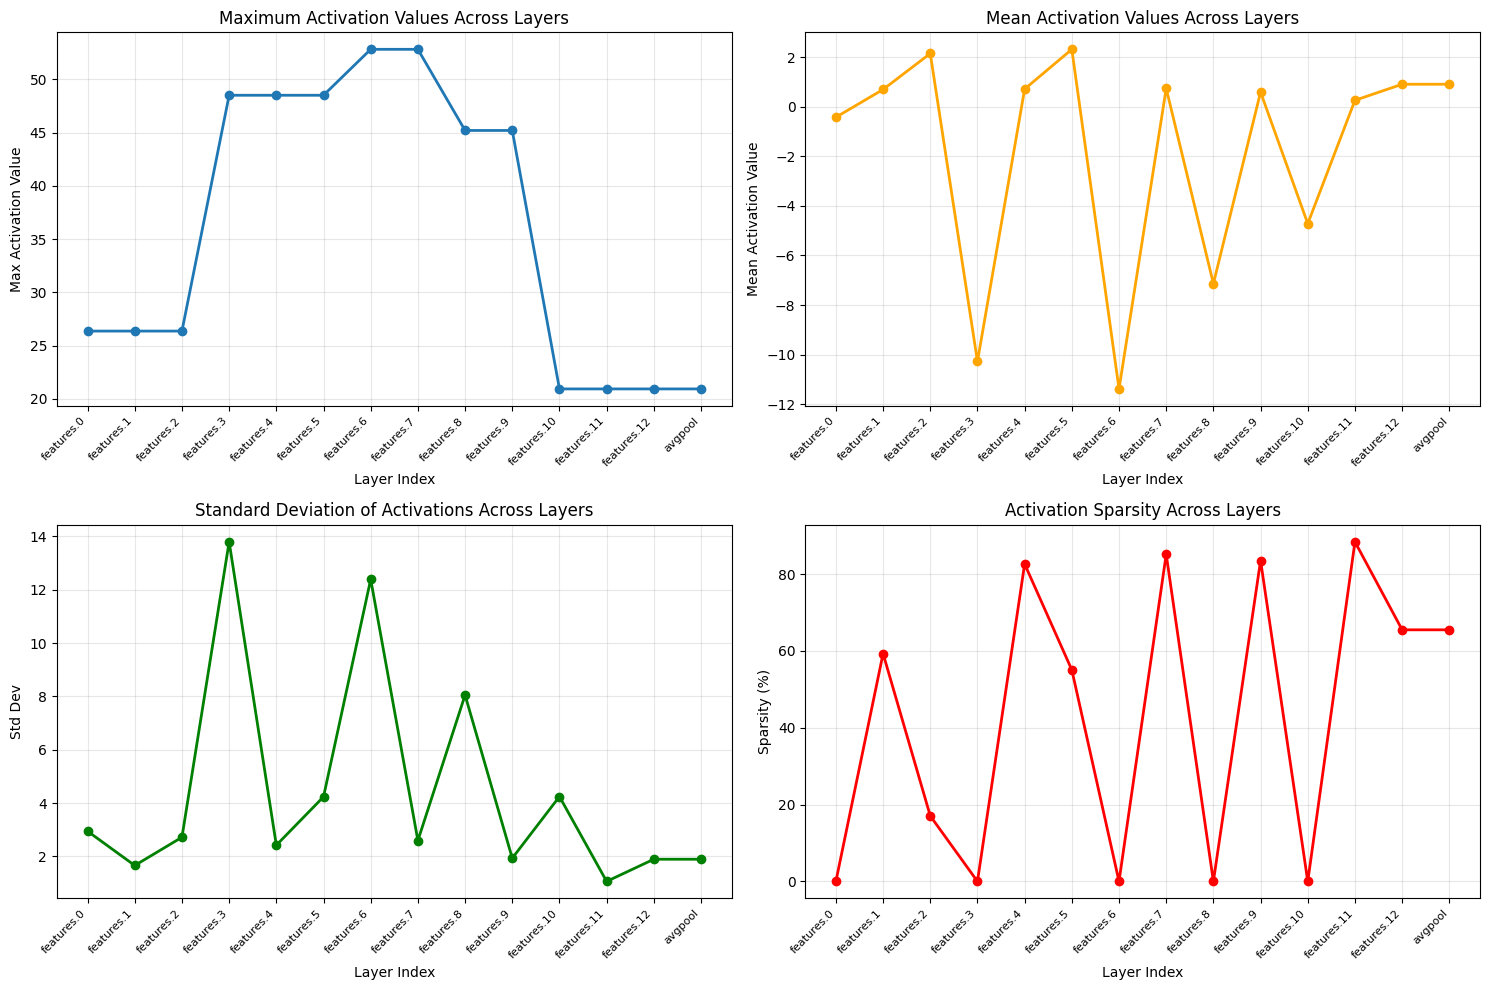

In [16]:
# Visualize activation statistics across layers
conv_layers = [(name, stats) for name, layer, output, stats in layer_outputs 
               if 'features' in name or name == 'avgpool']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Extract statistics
layer_names = [name for name, _ in conv_layers]
max_values = [stats['max'] for _, stats in conv_layers]
mean_values = [stats['mean'] for _, stats in conv_layers]
std_values = [stats['std'] for _, stats in conv_layers]
sparsity_values = [stats['sparsity'] * 100 for _, stats in conv_layers]

# Plot 1: Max activation values
axes[0, 0].plot(range(len(max_values)), max_values, 'o-', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Layer Index')
axes[0, 0].set_ylabel('Max Activation Value')
axes[0, 0].set_title('Maximum Activation Values Across Layers')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(len(layer_names)))
axes[0, 0].set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)

# Plot 2: Mean activation values
axes[0, 1].plot(range(len(mean_values)), mean_values, 'o-', linewidth=2, markersize=6, color='orange')
axes[0, 1].set_xlabel('Layer Index')
axes[0, 1].set_ylabel('Mean Activation Value')
axes[0, 1].set_title('Mean Activation Values Across Layers')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(len(layer_names)))
axes[0, 1].set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)

# Plot 3: Standard deviation
axes[1, 0].plot(range(len(std_values)), std_values, 'o-', linewidth=2, markersize=6, color='green')
axes[1, 0].set_xlabel('Layer Index')
axes[1, 0].set_ylabel('Std Dev')
axes[1, 0].set_title('Standard Deviation of Activations Across Layers')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(range(len(layer_names)))
axes[1, 0].set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)

# Plot 4: Sparsity
axes[1, 1].plot(range(len(sparsity_values)), sparsity_values, 'o-', linewidth=2, markersize=6, color='red')
axes[1, 1].set_xlabel('Layer Index')
axes[1, 1].set_ylabel('Sparsity (%)')
axes[1, 1].set_title('Activation Sparsity Across Layers')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(range(len(layer_names)))
axes[1, 1].set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
# Get the predicted class
final_output = layer_outputs[-1][2]  # Last layer output
predicted_idx = final_output.argmax(dim=1).item()

# Load ImageNet class labels
categories = weights.meta["categories"]
predicted_class = categories[predicted_idx]

print(f"\nPredicted class: {predicted_class}")
print(f"Confidence: {torch.softmax(final_output, dim=1)[0, predicted_idx].item():.4f}")

# Show top 5 predictions
probs = torch.softmax(final_output, dim=1)[0]
top5_probs, top5_indices = torch.topk(probs, 5)

print("\nTop 5 predictions:")
for i, (prob, idx) in enumerate(zip(top5_probs, top5_indices)):
    print(f"  {i+1}. {categories[idx]}: {prob.item():.4f}")


Predicted class: restaurant
Confidence: 0.1351

Top 5 predictions:
  1. restaurant: 0.1351
  2. guacamole: 0.1219
  3. wok: 0.1214
  4. broccoli: 0.0947
  5. Crock Pot: 0.0871


In [18]:
# Create a summary table of activation statistics for convolutional layers only
print("\n" + "="*100)
print("SUMMARY: Convolutional Layer Activation Statistics")
print("="*100)
print(f"{'Layer':<20} {'Type':<15} {'Shape':<20} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10} {'Sparsity':<10}")
print("-"*100)

for name, layer, output, stats in layer_outputs:
    if 'features' in name or name == 'avgpool' or name == 'input':
        layer_type = layer.__class__.__name__ if layer is not None else 'Input'
        shape_str = str(stats['shape'])
        print(f"{name:<20} {layer_type:<15} {shape_str:<20} "
              f"{stats['min']:>10.4f} {stats['max']:>10.4f} {stats['mean']:>10.4f} "
              f"{stats['std']:>10.4f} {stats['sparsity']*100:>9.2f}%")


SUMMARY: Convolutional Layer Activation Statistics
Layer                Type            Shape                       Min        Max       Mean        Std Sparsity  
----------------------------------------------------------------------------------------------------
input                Input           (1, 3, 224, 224)        -2.1179     2.6400     0.0615     1.5175      0.00%
features.0           Conv2d          (1, 64, 55, 55)        -23.1640    26.3609    -0.4169     2.9424      0.00%
features.1           ReLU            (1, 64, 55, 55)          0.0000    26.3609     0.7040     1.6570     59.30%
features.2           MaxPool2d       (1, 64, 27, 27)          0.0000    26.3609     2.1579     2.7158     17.06%
features.3           Conv2d          (1, 192, 27, 27)      -143.0630    48.5016   -10.2787    13.7956      0.00%
features.4           ReLU            (1, 192, 27, 27)         0.0000    48.5016     0.7214     2.4175     82.62%
features.5           MaxPool2d       (1, 192, 13, 13)   